# Reproducing the CARLA results of the thesis

This notebook regenerates every figure and number of the CARLA study (Chapter 6 and its
appendix) and checks them against the committed outputs and the thesis. It needs the
separate data folder `Atoms_Carla_thesis_data/`: copy its `data/` folder into the root of
this repository first (see `README.md`). No GPU, torch, CARLA or agent weights are needed,
and a run takes about 5 minutes.

| Step | What |
|---|---|
| 1 | `make_thesis_figures.py`: the 13 figures and their `.txt` sidecars |
| 2 | `bootstrap_auroc.py`: the route-level intervals of Section 6.2.1 |
| 3 | every regenerated sidecar compared with the committed one in `thesis_figures/` |
| 4 | the thesis's CARLA images compared with `thesis_figures/` (needs the Atari repository next to this one) |
| 5 | the figures, under their thesis labels |
| 6 | the headline numbers of Section 6.2, recomputed and set against the thesis |

Everything is written to `thesis_figures_reproduced/`, which git ignores, so the committed
figures are never touched. The one CARLA image this notebook cannot rebuild is the PGD
example in Chapter 4 (`@pgdAttack`). It runs the attack on the agent, which needs torch,
timm and the TFV6 weights (`helpful scripts/visualize_pgd_effect.py`).

In [1]:
from pathlib import Path
import hashlib, os, re, subprocess, sys, time

import pandas as pd
from IPython.display import Image, Markdown, display

ROOT = Path.cwd().resolve()
if not (ROOT / "make_thesis_figures.py").exists():   # started from notebooks/
    ROOT = ROOT.parent
assert (ROOT / "make_thesis_figures.py").exists(), "Start Jupyter from the repository root or notebooks/."

OUT        = ROOT / "thesis_figures_reproduced"   # everything written here (git-ignored)
COMMITTED  = ROOT / "thesis_figures"
THESIS_FIG = ROOT.parent / "ATOMs_SOLID" / "thesis" / "06_Carla_study" / "05_Figures"
RUN        = True     # False: only inspect what is already in OUT

DATA = ROOT / "data" / "TFV6"
needed = [DATA / "baseline_data_alt" / "baseline_2.npz", DATA / "results_alt" / "10 clusters",
          DATA / "test_data_alt" / "test_labeled.npz", DATA / "val_data_alt" / "val_labeled.npz"]
missing = [str(p.relative_to(ROOT)) for p in needed if not p.exists()]
assert not missing, ("Data folder not found. Copy data/ from Atoms_Carla_thesis_data/ into "
                     f"the repository root. Missing: {missing}")
OUT.mkdir(exist_ok=True)
print("repository :", ROOT)
print("python     :", sys.executable)
print("thesis dir :", THESIS_FIG if THESIS_FIG.exists() else "not found (step 4 is skipped)")

repository : C:\Users\paulk\Desktop\Unistuff\Masterarbeit\Code\PCLA
python     : C:\Users\paulk\miniconda3\envs\atoms3\python.exe
thesis dir : C:\Users\paulk\Desktop\Unistuff\Masterarbeit\Code\ATOMs_SOLID\thesis\06_Carla_study\05_Figures


In [2]:
def run(script, *args):
    # Run one script with this kernel's Python, keep its log, fail loudly.
    cmd = [sys.executable, str(ROOT / script), *map(str, args)]
    env = {**os.environ, "PYTHONIOENCODING": "utf-8", "MPLBACKEND": "Agg"}
    t0 = time.time()
    p = subprocess.run(cmd, cwd=ROOT, env=env, capture_output=True, text=True,
                       encoding="utf-8", errors="replace")
    log = OUT / f"{Path(script).stem}.log"
    log.write_text(p.stdout + "\n--- stderr ---\n" + p.stderr, encoding="utf-8")
    print(f"{'ok ' if p.returncode == 0 else 'ERR'} {script:24s} {time.time() - t0:5.0f} s   "
          f"{log.relative_to(ROOT)}")
    if p.returncode != 0:
        print(p.stderr[-3000:])
        raise RuntimeError(f"{script} failed, see {log}")

def show(path, width=760):
    # Display a figure, downscaled so that a saved notebook stays small.
    from io import BytesIO
    from PIL import Image as PILImage
    path = Path(path)
    if not path.exists():
        print(f"[missing] {path}")
        return
    im = PILImage.open(path).convert("RGB")
    im.thumbnail((int(1.25 * width), 5 * width))
    buf = BytesIO()
    im.save(buf, format="PNG", optimize=True)
    display(Image(data=buf.getvalue(), width=width))

## Steps 1 and 2: regenerate

In [3]:
if RUN:
    run("make_thesis_figures.py", "--out-dir", OUT)
    run("bootstrap_auroc.py", "--out-dir", OUT)

ok  make_thesis_figures.py      39 s   thesis_figures_reproduced\make_thesis_figures.log


ok  bootstrap_auroc.py         187 s   thesis_figures_reproduced\bootstrap_auroc.log


## Step 3: do the regenerated sidecars match the committed ones?

Each figure's `.txt` sidecar holds the exact numbers behind it. The line naming the
source path is skipped, because it contains the absolute path of the machine that wrote
it. The PNGs are not compared, because matplotlib takes the first available serif font
from `thesis_style.py`, so they can differ between machines while the numbers agree.

In [4]:
def lines(p):
    text = Path(p).read_text(encoding="utf-8", errors="replace").replace("\r", "")
    return [l for l in text.splitlines() if not l.startswith("# source:")]

rows = []
for f in sorted(OUT.glob("*.txt")):
    ref = COMMITTED / f.name
    rows.append((f.name, "no committed copy" if not ref.exists()
                 else "identical" if lines(f) == lines(ref) else "DIFFERENT"))
side = pd.DataFrame(rows, columns=["sidecar", "status"])
print(side.status.value_counts().to_string())
display(side)

status
identical    15


,sidecar,status
0,attention_by_cluster.txt,identical
1,attention_per_cluster.txt,identical
2,attention_per_cluster_frames.txt,identical
3,auroc_bootstrap.txt,identical
4,auroc_gmm_vs_single.txt,identical
5,auroc_per_perturbation_gmm.txt,identical
6,auroc_per_perturbation_vs_K.txt,identical
7,auroc_val_test_vs_K.txt,identical
8,gmm_auc_vs_K.txt,identical
9,knn_k_selection.txt,identical


## Step 4: are the thesis images the committed figures?

The thesis embeds copies of the PNGs under `thesis/06_Carla_study/05_Figures/` in the
Atari repository. Each must be byte-identical to the committed file in `thesis_figures/`,
whose sidecar step 3 has just reproduced.

In [5]:
LABELS = {
    "pca_baseline_run_vs_gmm": "@carlaPca", "attention_by_cluster": "@attentions",
    "auroc_val_test_vs_K": "@valSetSelection", "auroc_per_perturbation_gmm": "@aurocs",
    "score_dist_per_perturbation": "@distributionShift", "live_scores_brightness_scale": "@liveBright",
    "attention_per_cluster_frames": "@attentionPerCluster (appendix)",
    "auroc_per_perturbation_vs_K": "@perturbationVsK (appendix)",
    "knn_k_selection": "@knnSelection (appendix)", "auroc_gmm_vs_single": "@clusterAdvantage (appendix)",
    "live_scores_gaussian_noise": "@liveNoise (appendix)", "live_scores_pgd": "@livePgd (appendix)",
}
md5 = lambda p: hashlib.md5(Path(p).read_bytes()).hexdigest()
if THESIS_FIG.exists():
    chain = [(label, name + ".png",
              (THESIS_FIG / f"{name}.png").exists() and md5(THESIS_FIG / f"{name}.png") == md5(COMMITTED / f"{name}.png"))
             for name, label in LABELS.items()]
    display(pd.DataFrame(chain, columns=["thesis label", "file", "thesis copy == committed file"]))
else:
    print("The Atari repository (with thesis/) is not next to this one; step skipped.")

,thesis label,file,thesis copy == committed file
0,@carlaPca,pca_baseline_run_vs_gmm.png,True
1,@attentions,attention_by_cluster.png,True
2,@valSetSelection,auroc_val_test_vs_K.png,True
3,@aurocs,auroc_per_perturbation_gmm.png,True
4,@distributionShift,score_dist_per_perturbation.png,True
5,@liveBright,live_scores_brightness_scale.png,True
6,@attentionPerCluster (appendix),attention_per_cluster_frames.png,True
7,@perturbationVsK (appendix),auroc_per_perturbation_vs_K.png,True
8,@knnSelection (appendix),knn_k_selection.png,True
9,@clusterAdvantage (appendix),auroc_gmm_vs_single.png,True


## Step 5: the figures

**@carlaPca**, `pca_baseline_run_vs_gmm.png`

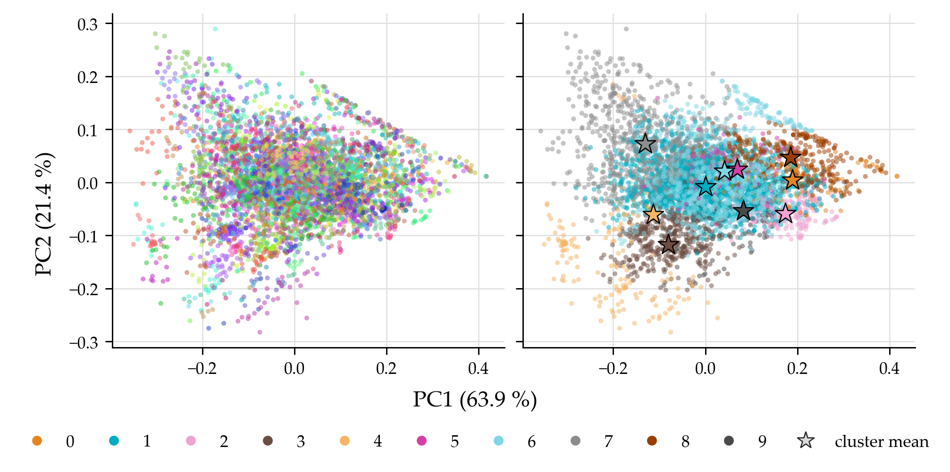

**@attentions**, `attention_by_cluster.png`

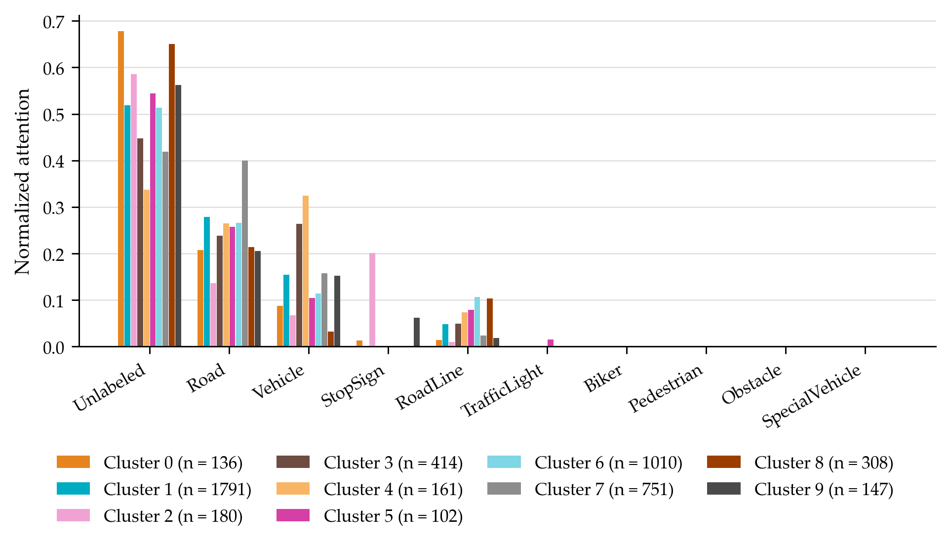

**@valSetSelection**, `auroc_val_test_vs_K.png`

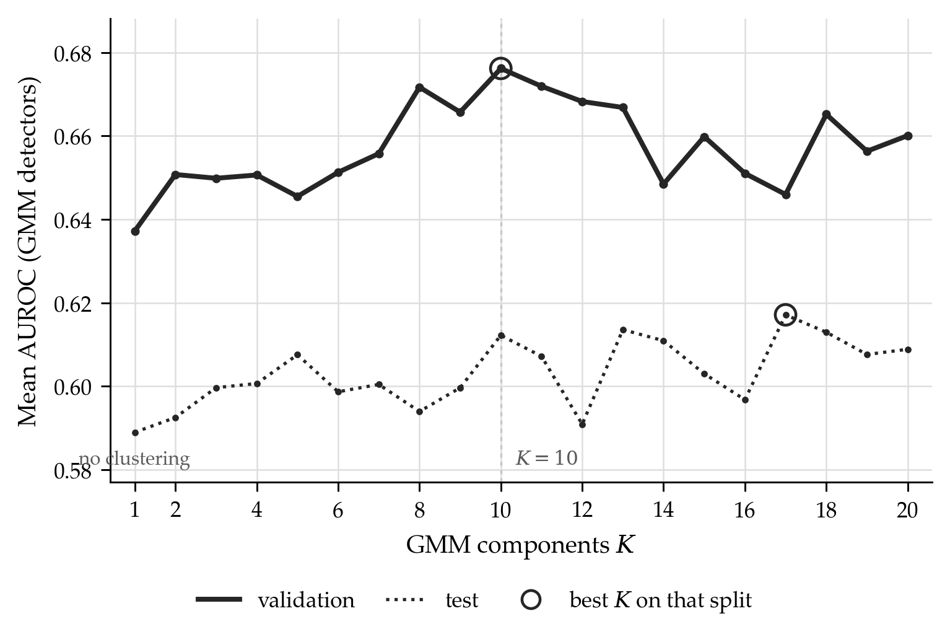

**@aurocs**, `auroc_per_perturbation_gmm.png`

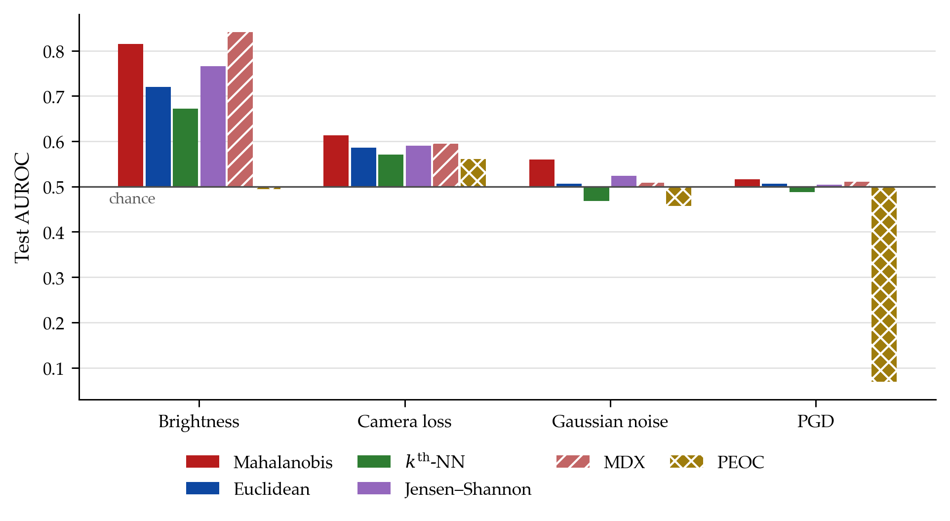

**@distributionShift**, `score_dist_per_perturbation.png`

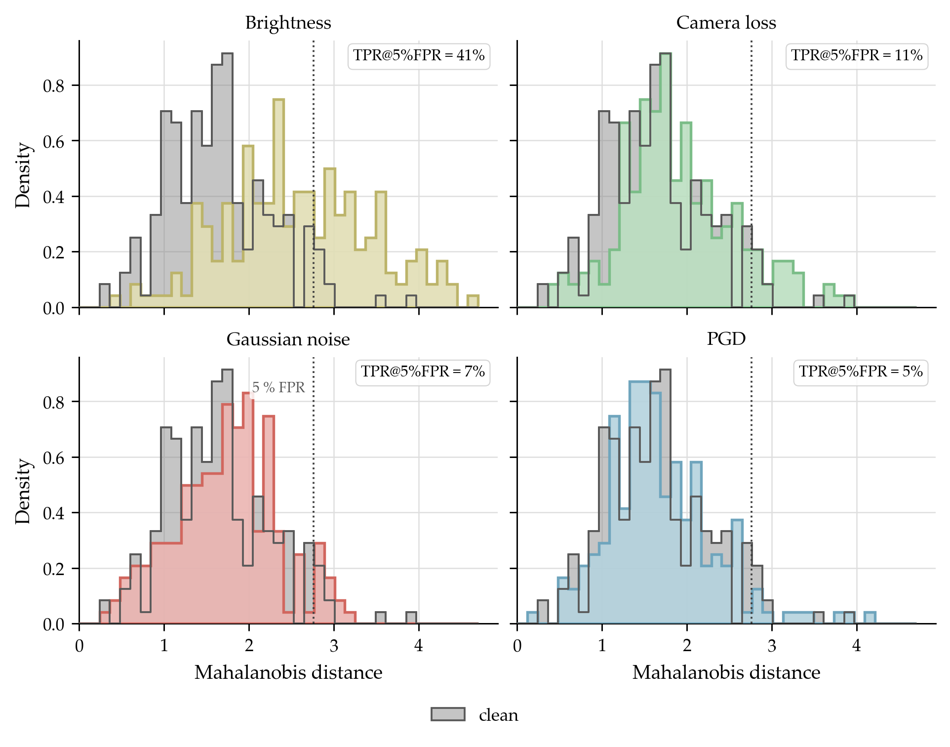

**@liveBright**, `live_scores_brightness_scale.png`

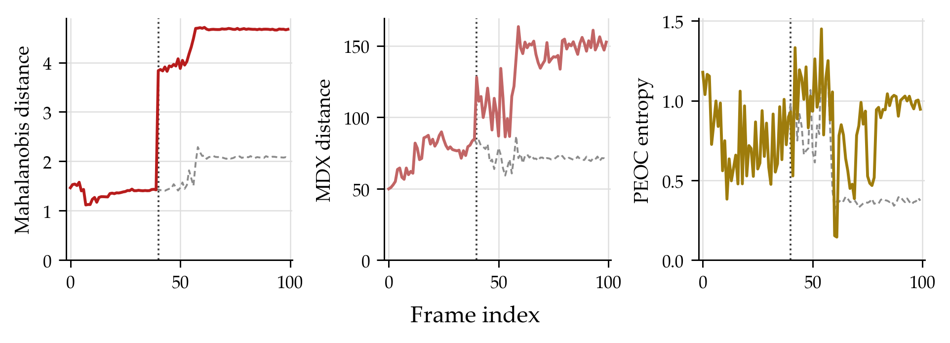

**@attentionPerCluster (appendix)**, `attention_per_cluster_frames.png`

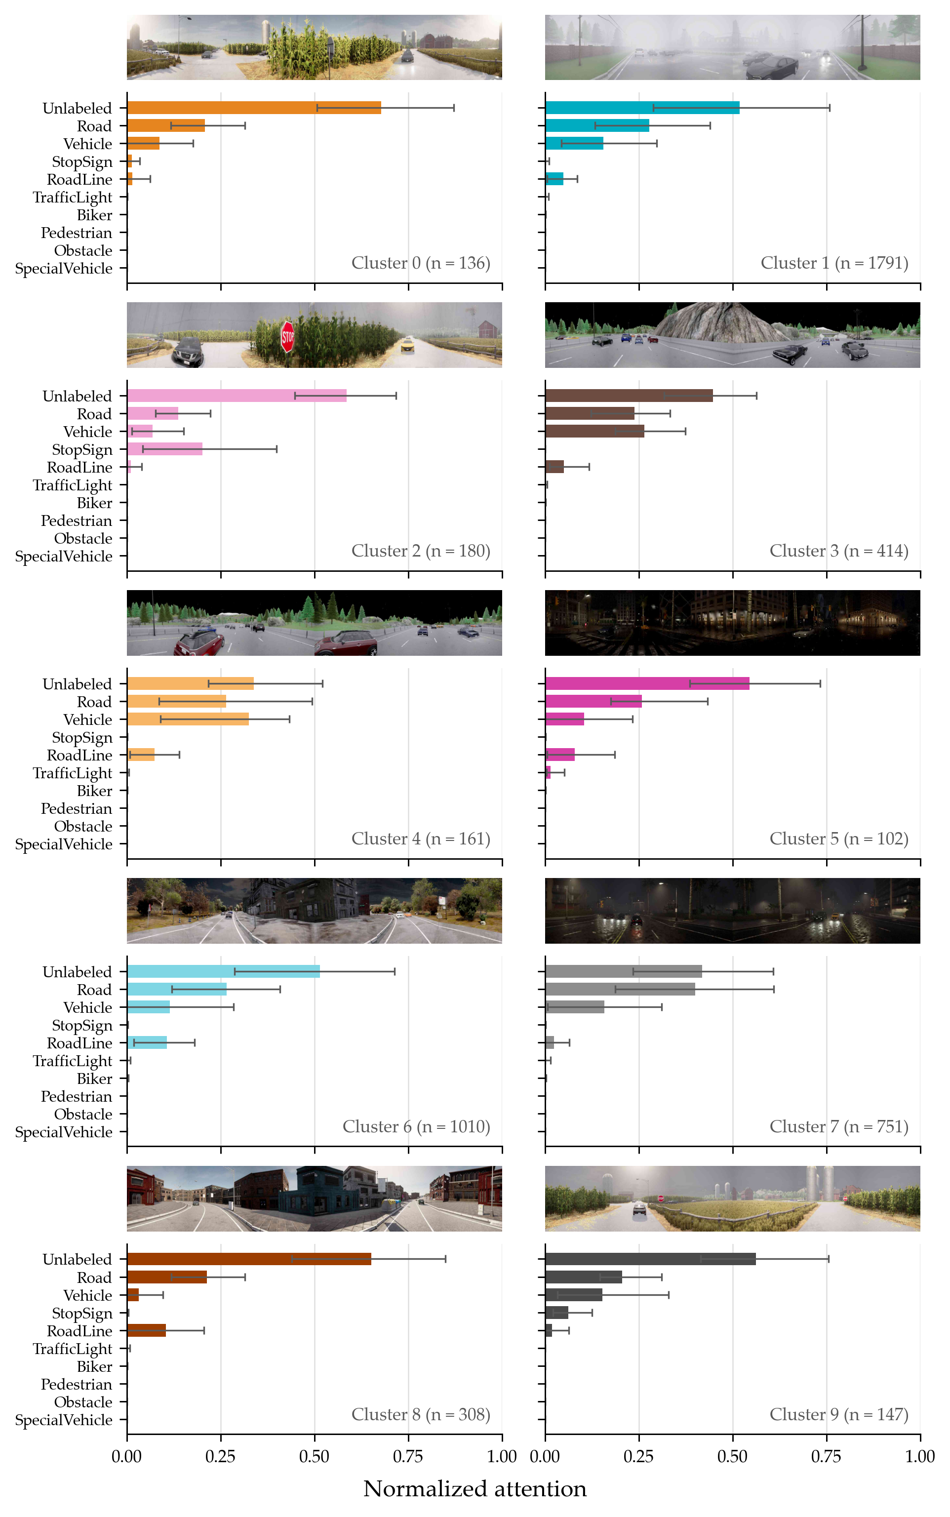

**@perturbationVsK (appendix)**, `auroc_per_perturbation_vs_K.png`

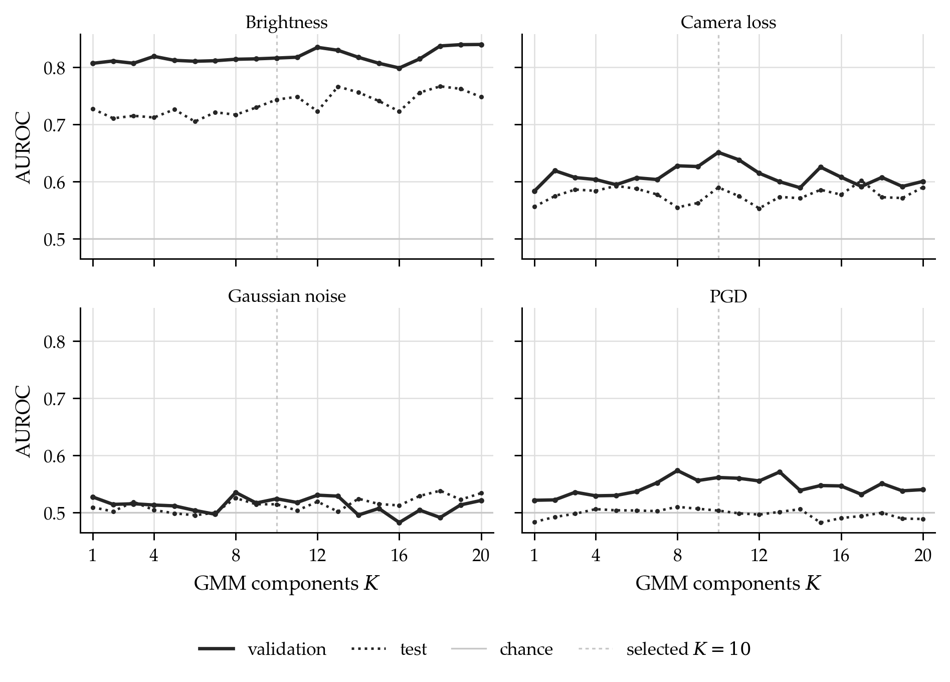

**@knnSelection (appendix)**, `knn_k_selection.png`

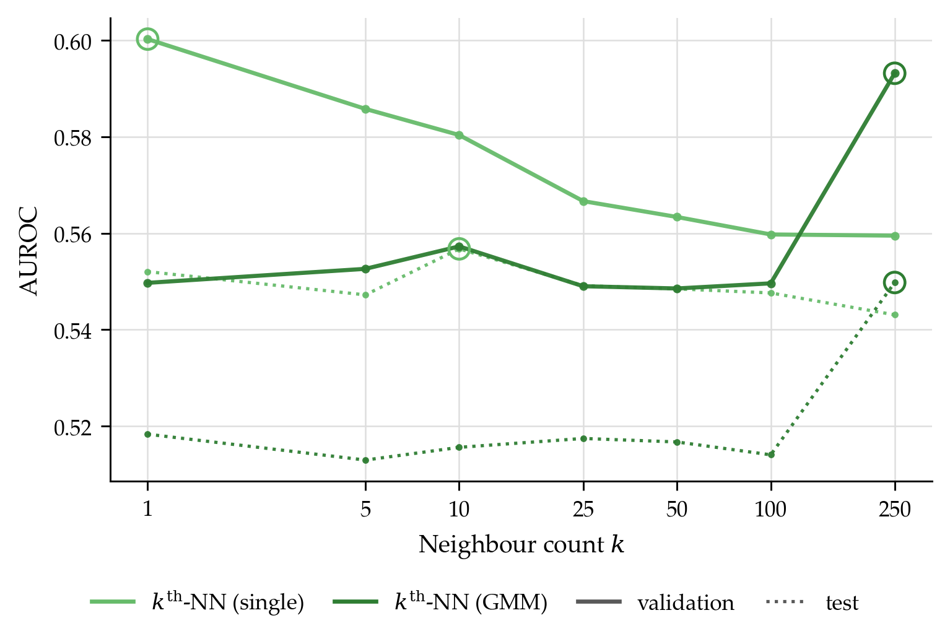

**@clusterAdvantage (appendix)**, `auroc_gmm_vs_single.png`

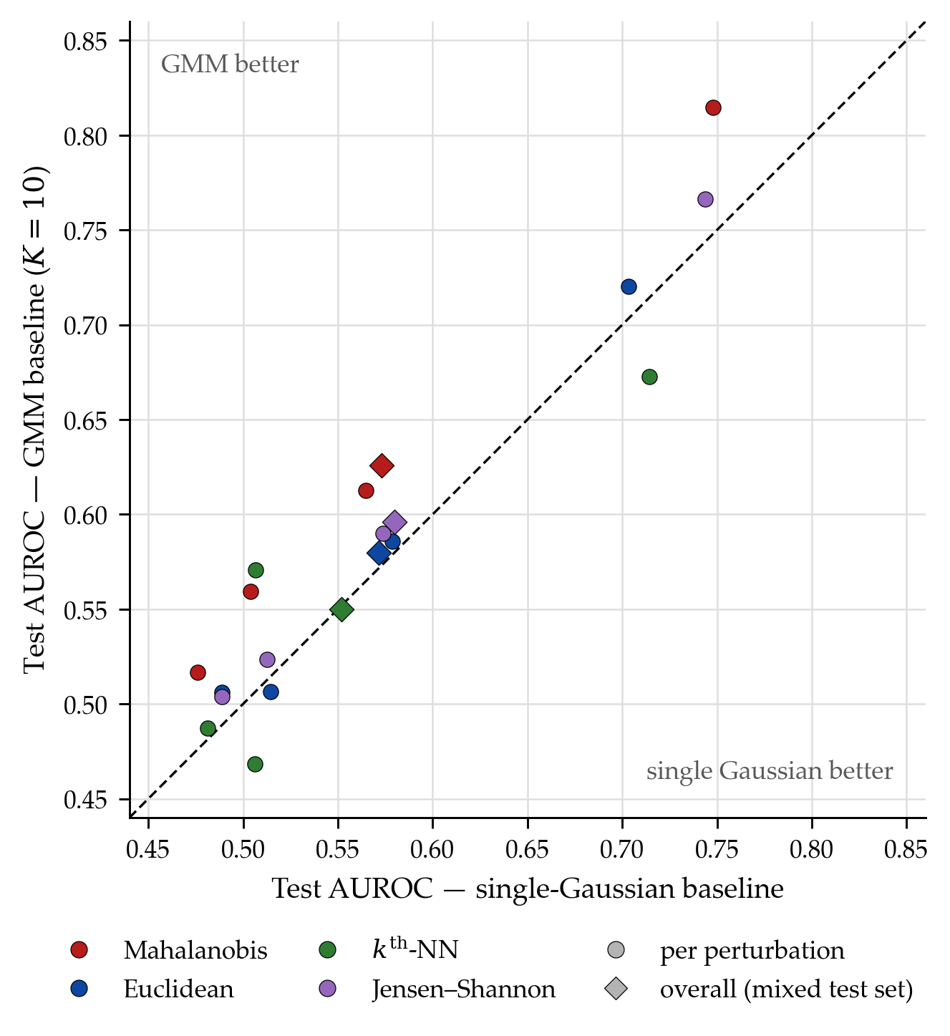

**@liveNoise (appendix)**, `live_scores_gaussian_noise.png`

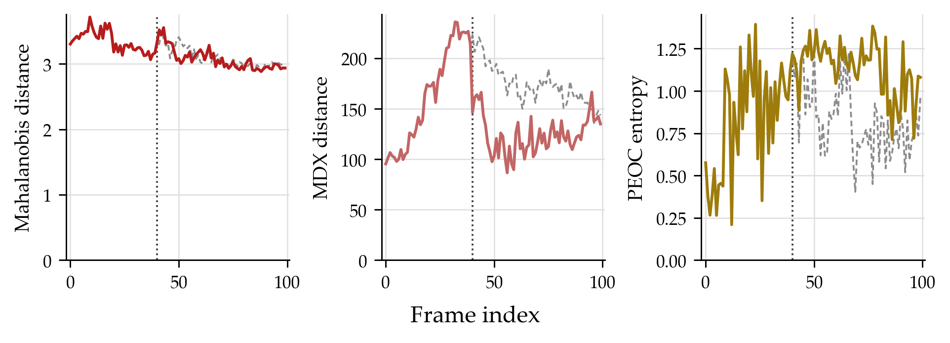

**@livePgd (appendix)**, `live_scores_pgd.png`

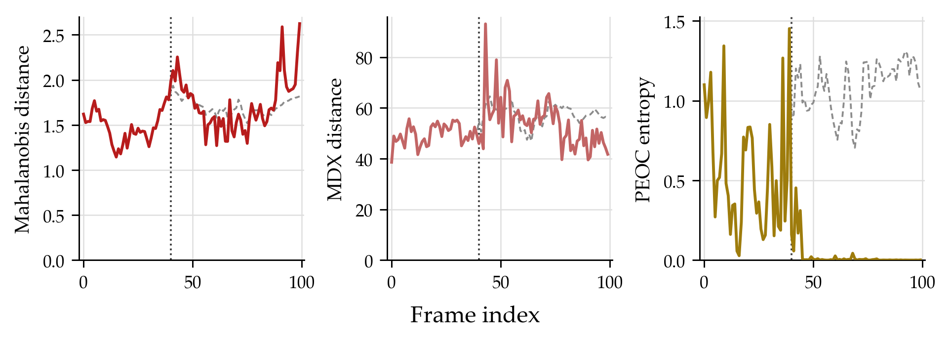

In [6]:
for name, label in LABELS.items():
    display(Markdown(f"**{label}**, `{name}.png`"))
    show(OUT / f"{name}.png")

## Step 6: headline numbers

The numbers Section 6.2 reports, read from this run's sidecars and set against the
value the thesis states. A number matches when it agrees at the precision the
thesis prints, rounding half up (0.5595 is printed as 0.560).

In [7]:
def text(name):
    return (OUT / name).read_text(encoding="utf-8").replace("\r", "")

def section(name, title):
    # Lines of one sidecar section (a title line followed by a line of dashes).
    t = text(name).splitlines()
    for i, l in enumerate(t[:-1]):
        if l.strip() == title and set(t[i + 1].strip()) == {"-"}:
            out = []
            for l2 in t[i + 2:]:
                if l2 and not l2.startswith(" "):
                    break
                out.append(l2)
            return "\n".join(out)
    raise KeyError(f"{title} not in {name}")

def grab(pattern, s):
    m = re.search(pattern, s)
    if not m:
        raise KeyError(pattern)
    return m.group(1)

r3 = lambda x: f"{float(x):.3f}"
s3 = lambda x: f"{float(x):+.3f}"
def ci(s, signed=False):
    lo, hi = re.findall(r"[-+]?\d+\.\d+", s)[:2]
    f = s3 if signed else r3
    return f"[{f(lo)}, {f(hi)}]"

checks = []
def check(claim, thesis, value):
    # Numbers match within the precision the thesis prints (so 0.5595 matches 0.560);
    # composite values (intervals, lists) must match as printed.
    try:
        dp = len(thesis.split(".")[1]) if "." in thesis else 0
        ok = abs(float(thesis) - float(value)) <= 0.5 * 10 ** -dp + 1e-9
    except ValueError:
        ok = str(thesis) == str(value)
    checks.append(dict(claim=claim, thesis=thesis, reproduced=value, match=ok))

pp = "auroc_per_perturbation_gmm.txt"
for pert, md_, mdx in [("Brightness", "0.815", "0.841"), ("Camera loss", "0.613", "0.594"),
                       ("Gaussian noise", "0.560", "0.508"), ("PGD", "0.517", "0.510")]:
    sec = section(pp, pert)
    check(f"MD test AUROC, {pert}", md_, grab(r"Mahalanobis \(MD\): ([\d.]+)", sec))
    check(f"MDX test AUROC, {pert}", mdx, grab(r"MDX: ([\d.]+)", sec))
check("PEOC test AUROC, PGD (the clearly inverted score)", "0.069",
      grab(r"PEOC: ([\d.]+)", section(pp, "PGD")))

bs = "auroc_bootstrap.txt"
test = section(bs, "test split")
pooled = float(grab(r"MD, all four perturbations: ([\d.]+)", test))
check("pooled MD test AUROC, all four perturbations", "0.6258", f"{pooled:.4f}")
check("MD route-level 95% CI, brightness", "[0.734, 0.889]",
      ci(grab(r"Brightness: [\d.]+\s+95% CI (\[[^\]]+\])", test)))
check("MD route-level 95% CI, camera loss", "[0.542, 0.690]",
      ci(grab(r"Camera loss: [\d.]+\s+95% CI (\[[^\]]+\])", test)))
m = re.search(r"Brightness: MD [\d.]+ over \w+ [\d.]+, margin ([-+][\d.]+) 95% CI (\[[^\]]+\])", text(bs))
check("brightness: MD margin over the second-best distance", "+0.048 [+0.005, +0.089]",
      f"{s3(m.group(1))} {ci(m.group(2), signed=True)}")
m = re.search(r"offset of the plotted curves at K = 10: ([-+][\d.]+)\s+95% CI (\[[^\]]+\])", text(bs))
check("val minus test offset of the plotted curve at K = 10", "+0.064 [+0.005, +0.120]",
      f"{s3(m.group(1))} {ci(m.group(2), signed=True)}")

pca = text("pca_baseline_run_vs_gmm.txt")
check("PC1 explained variance (%)", "63.88", grab(r"PC1: ([\d.]+) %", pca))
check("PC2 explained variance (%)", "21.42", grab(r"PC2: ([\d.]+) %", pca))
check("component sizes at K = 10", "102, 136, 147, 161, 180, 308, 414, 751, 1010, 1791",
      grab(r"sizes ascending: ([\d, ]+)", pca).strip())

vt = text("auroc_val_test_vs_K.txt")
peak, peak_k = re.search(r"peak: ([\d.]+)\s+\(at K = (\d+)\)", vt).groups()   # first = validation
check("validation criterion peak (selects K = 10)", "0.676 at K = 10", f"{r3(peak)} at K = {peak_k}")
check("validation criterion, single Gaussian (K = 1)", "0.637", grab(r"validation at K = 1: ([\d.]+)", vt))
check("test counterpart, single Gaussian (K = 1)", "0.589", grab(r"test at K = 1: ([\d.]+)", vt))
check("clustered counts beating K = 1, validation", "19 of 19", grab(r"beating K = 1 on validation: (\d+ of \d+)", vt))
check("clustered counts beating K = 1, test", "19 of 19", grab(r"beating K = 1 on test: (\d+ of \d+)", vt))

checks = pd.DataFrame(checks)
print(f"{checks.match.sum()} of {len(checks)} headline numbers reproduced")
with pd.option_context("display.max_colwidth", 70):
    display(checks)

22 of 22 headline numbers reproduced


,claim,thesis,reproduced,match
0,"MD test AUROC, Brightness",0.815,0.8146,True
1,"MDX test AUROC, Brightness",0.841,0.8409,True
2,"MD test AUROC, Camera loss",0.613,0.6127,True
3,"MDX test AUROC, Camera loss",0.594,0.5942,True
4,"MD test AUROC, Gaussian noise",0.560,0.5595,True
5,"MDX test AUROC, Gaussian noise",0.508,0.5082,True
6,"MD test AUROC, PGD",0.517,0.5166,True
7,"MDX test AUROC, PGD",0.510,0.5103,True
8,"PEOC test AUROC, PGD (the clearly inverted score)",0.069,0.0694,True
9,"pooled MD test AUROC, all four perturbations",0.6258,0.6258,True
